<a href="https://www.kaggle.com/code/lalit7881/exoplanet-archive-intelligence-99-92?scriptVersionId=306567604" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/nasa-exoplanet-archive-intelligence/nasa_exoplanet_intelligence.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/nasa-exoplanet-archive-intelligence/nasa_exoplanet_intelligence.csv")

In [3]:
df.head()

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [4]:
df.tail()

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.28909,1.000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.89110,6.710,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.15551,1.382,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6149,TOI-375 d,TOI-375,1,3,Radial Velocity,2026.0,Multiple Observatories,297.90000,13.600,445.595427,...,47.149903,-77.383327,0,Gas Giant,False,True,True,Mid(100-500pc),G-type(Sun-like),Long(100-365d)


In [5]:
df.info


<bound method DataFrame.info of                planet_name           host_star  n_stars  n_planets  \
0            Kepler-1167 b         Kepler-1167        1          1   
1            Kepler-1740 b         Kepler-1740        1          1   
2            Kepler-1581 b         Kepler-1581        1          1   
3             Kepler-644 b          Kepler-644        1          1   
4            Kepler-1752 b         Kepler-1752        1          1   
...                    ...                 ...      ...        ...   
6145  KMT-2024-BLG-1870L b  KMT-2024-BLG-1870L        1          1   
6146            TOI-2267 b          TOI-2267 A        2          3   
6147             TOI-813 b             TOI-813        1          1   
6148            LHS 1903 b            LHS 1903        1          4   
6149             TOI-375 d             TOI-375        1          3   

     discovery_method  disc_year  \
0             Transit     2016.0   
1             Transit     2021.0   
2             Trans

In [6]:
df.dtypes

planet_name              object
host_star                object
n_stars                   int64
n_planets                 int64
discovery_method         object
disc_year               float64
disc_facility            object
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
equilibrium_temp_k      float64
orbital_eccentricity    float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_age_gyr            float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
ra                      float64
dec                     float64
controversial_flag        int64
planet_type              object
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category            object
star_type                object
orbital_period_cat       object
dtype: o

In [7]:
df.shape

(6150, 31)

In [8]:
df.isnull().sum()

planet_name                0
host_star                  0
n_stars                    0
n_planets                  0
discovery_method           0
disc_year                  1
disc_facility              0
orbital_period_days      334
planet_radius_earth       50
planet_mass_earth         31
equilibrium_temp_k      1563
orbital_eccentricity     938
semi_major_axis_au       316
star_temp_k              290
star_radius_sun          314
star_mass_sun              8
star_age_gyr            1311
star_surface_gravity     318
star_metallicity         550
dist_from_earth_pc        27
star_vmag                295
ra                         0
dec                        0
controversial_flag         0
planet_type                0
habitable_zone_flag        0
multi_planet_system        0
is_recent_discovery        0
dist_category              0
star_type                  0
orbital_period_cat         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='object')

In [11]:
df.nunique()

planet_name             6150
host_star               4582
n_stars                    4
n_planets                  8
discovery_method          11
disc_year                 34
disc_facility             73
orbital_period_days     5802
planet_radius_earth     2136
planet_mass_earth       2817
equilibrium_temp_k      1876
orbital_eccentricity     611
semi_major_axis_au      3536
star_temp_k             2295
star_radius_sun         1808
star_mass_sun           1206
star_age_gyr             662
star_surface_gravity    1250
star_metallicity         618
dist_from_earth_pc      4469
star_vmag               3220
ra                      4579
dec                     4579
controversial_flag         2
planet_type                7
habitable_zone_flag        2
multi_planet_system        2
is_recent_discovery        2
dist_category              5
star_type                  8
orbital_period_cat         6
dtype: int64

In [12]:
df.describe()

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_surface_gravity,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag
count,6150.000000,6150.000000,6149.000000,5.816000e+03,6100.000000,6119.000000,4587.000000,5212.000000,5834.000000,5860.000000,5836.000000,6142.000000,4839.000000,5832.000000,5600.000000,6123.000000,5855.000000,6150.000000,6150.000000,6150.000000
mean,1.103740,1.774309,2016.986339,7.359421e+04,5.841983,406.787994,912.895472,0.079236,15.718494,5398.163985,1.503790,0.936813,4.383390,4.384138,0.015630,711.669811,12.546162,232.888731,18.049038,0.007967
std,0.343093,1.158362,4.964920,5.273718e+06,5.436387,1142.866060,464.271129,0.152881,349.043858,1747.460059,3.950248,0.409758,3.001037,0.441306,0.188338,1212.136251,3.062720,91.676467,37.074883,0.088912
min,1.000000,1.000000,1992.000000,9.070629e-02,0.309800,0.020000,34.000000,0.000000,0.004400,415.000000,0.011500,0.009400,0.000000,0.541000,-1.000000,1.301190,0.872000,0.185606,-88.121111,0.000000
25%,1.000000,1.000000,2014.000000,4.347374e+00,1.820750,4.190000,566.000000,0.000000,0.052300,4904.750000,0.770000,0.770000,2.340000,4.292000,-0.080000,100.855000,10.611000,173.284640,-11.166116,0.000000
50%,1.000000,1.000000,2016.000000,1.112522e+01,2.840000,9.270000,818.000000,0.000000,0.102015,5546.000000,0.951690,0.940000,3.980000,4.453000,0.020000,376.658000,13.236000,284.914973,39.127119,0.000000
75%,1.000000,2.000000,2021.000000,3.976274e+01,11.990000,190.849000,1164.000000,0.091000,0.307750,5900.000000,1.250000,1.089500,5.665000,4.580000,0.130000,835.808000,14.943000,293.226852,45.384217,0.000000
max,4.000000,8.000000,2026.000000,4.020000e+08,87.205870,9534.852210,4050.000000,0.950000,19000.000000,57000.000000,88.475000,10.940000,16.100000,8.070000,0.600000,8500.000000,44.610000,359.974984,86.860343,1.000000


## EDA

In [13]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 7)

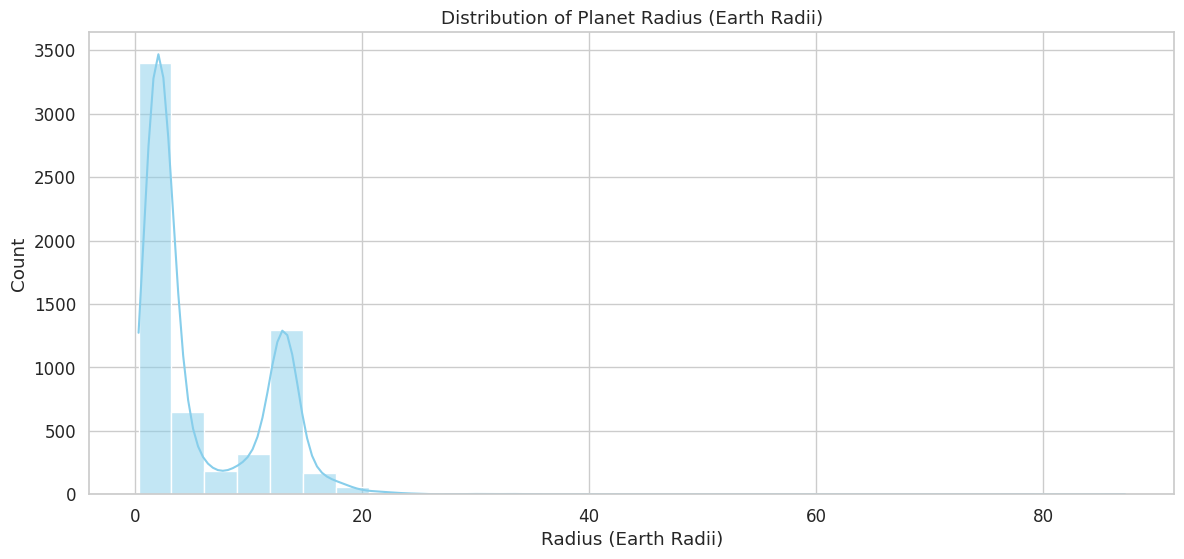

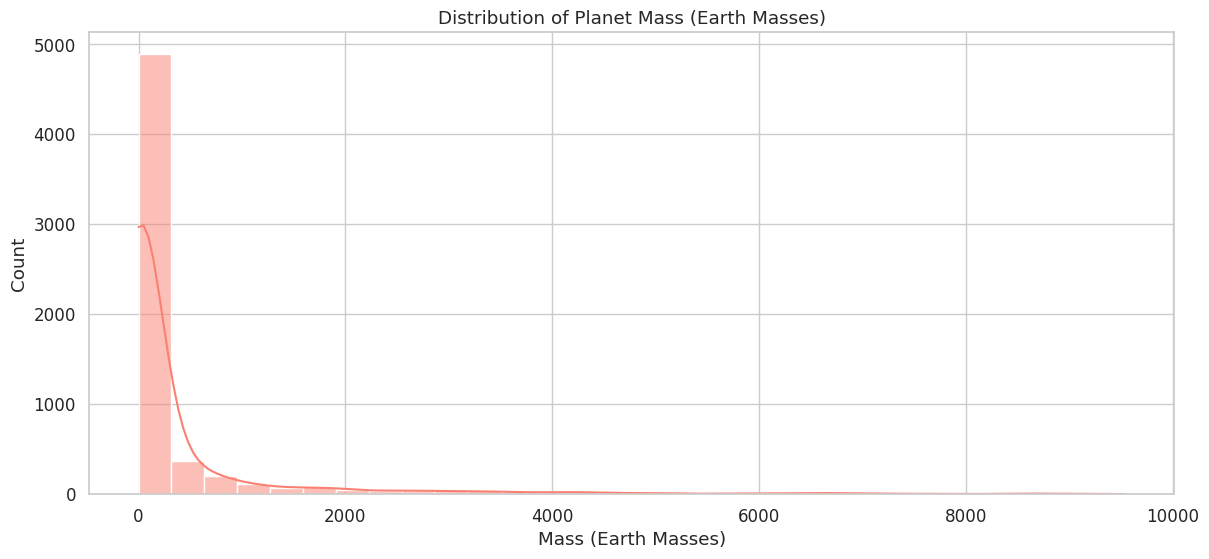

In [14]:
plt.figure(figsize=(14,6))
sns.histplot(df['planet_radius_earth'], bins=30, color='skyblue', kde=True)
plt.title('Distribution of Planet Radius (Earth Radii)')
plt.xlabel('Radius (Earth Radii)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(14,6))
sns.histplot(df['planet_mass_earth'], bins=30, color='salmon', kde=True)
plt.title('Distribution of Planet Mass (Earth Masses)')
plt.xlabel('Mass (Earth Masses)')
plt.ylabel('Count')
plt.show()

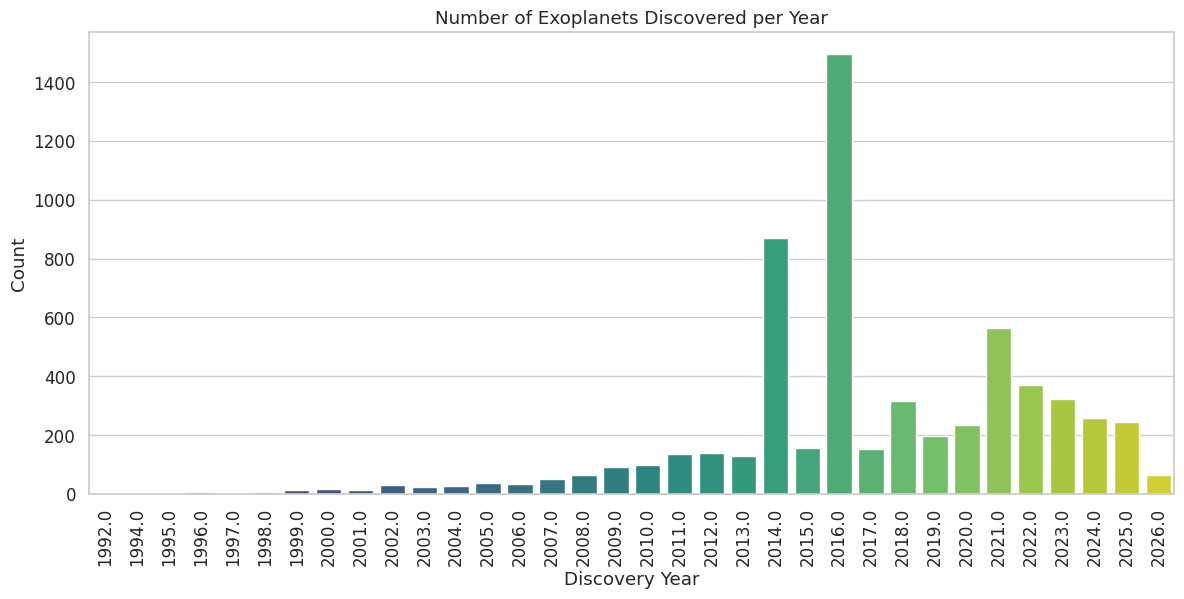

In [15]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='disc_year', palette='viridis')
plt.xticks(rotation=90)
plt.title('Number of Exoplanets Discovered per Year')
plt.xlabel('Discovery Year')
plt.ylabel('Count')
plt.show()

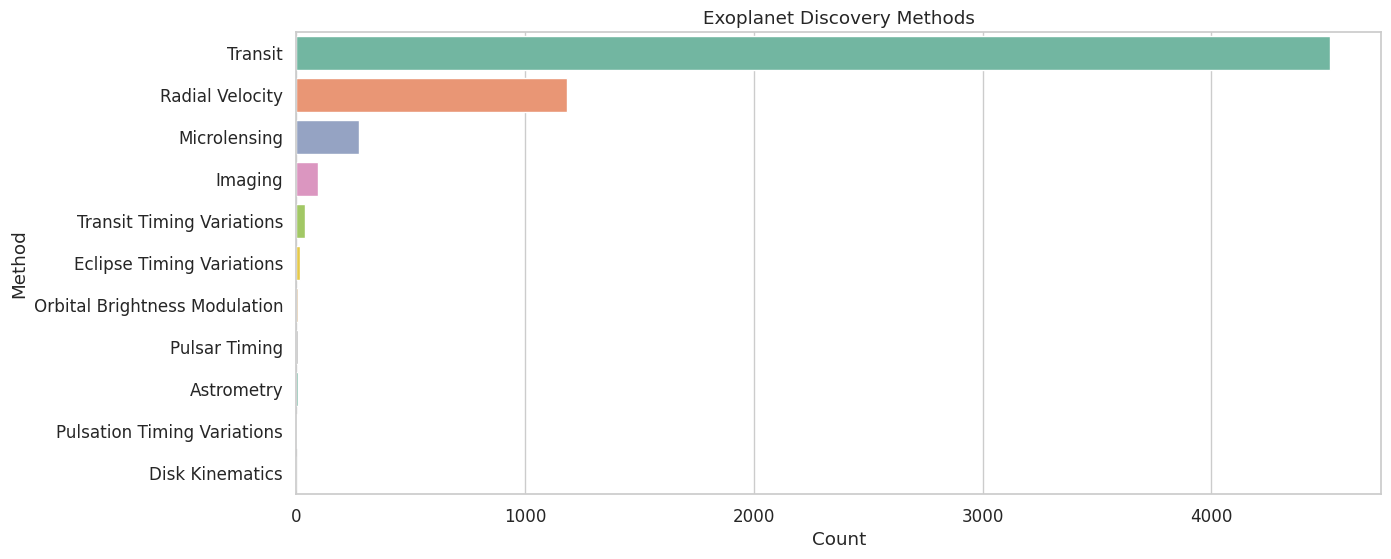

In [16]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, y='discovery_method', palette='Set2', order=df['discovery_method'].value_counts().index)
plt.title('Exoplanet Discovery Methods')
plt.xlabel('Count')
plt.ylabel('Method')
plt.show()


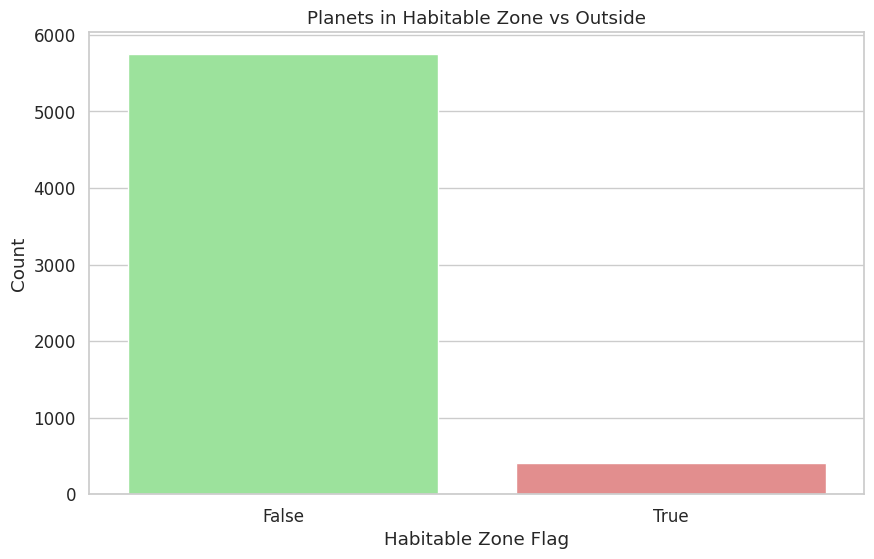

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='habitable_zone_flag', palette=['lightgreen','lightcoral'])
plt.title('Planets in Habitable Zone vs Outside')
plt.xlabel('Habitable Zone Flag')
plt.ylabel('Count')
plt.show()

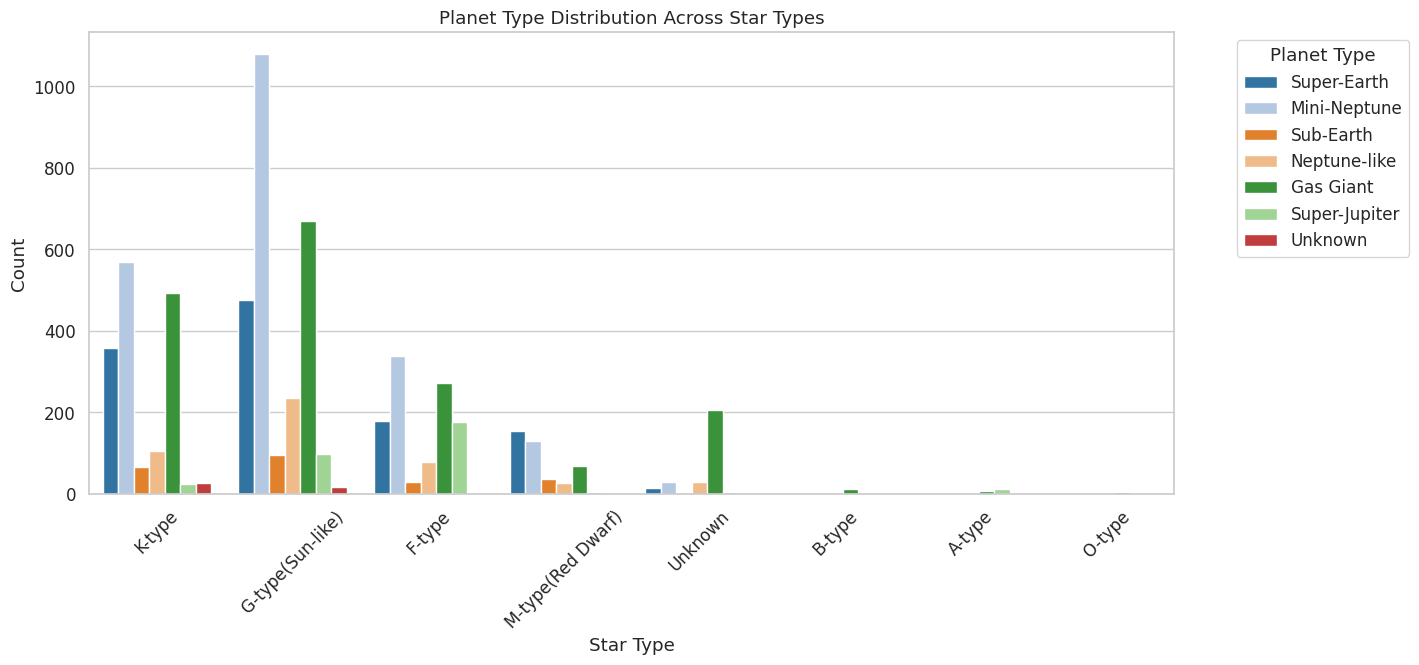

In [18]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='star_type', hue='planet_type', palette='tab20')
plt.title('Planet Type Distribution Across Star Types')
plt.xlabel('Star Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Planet Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


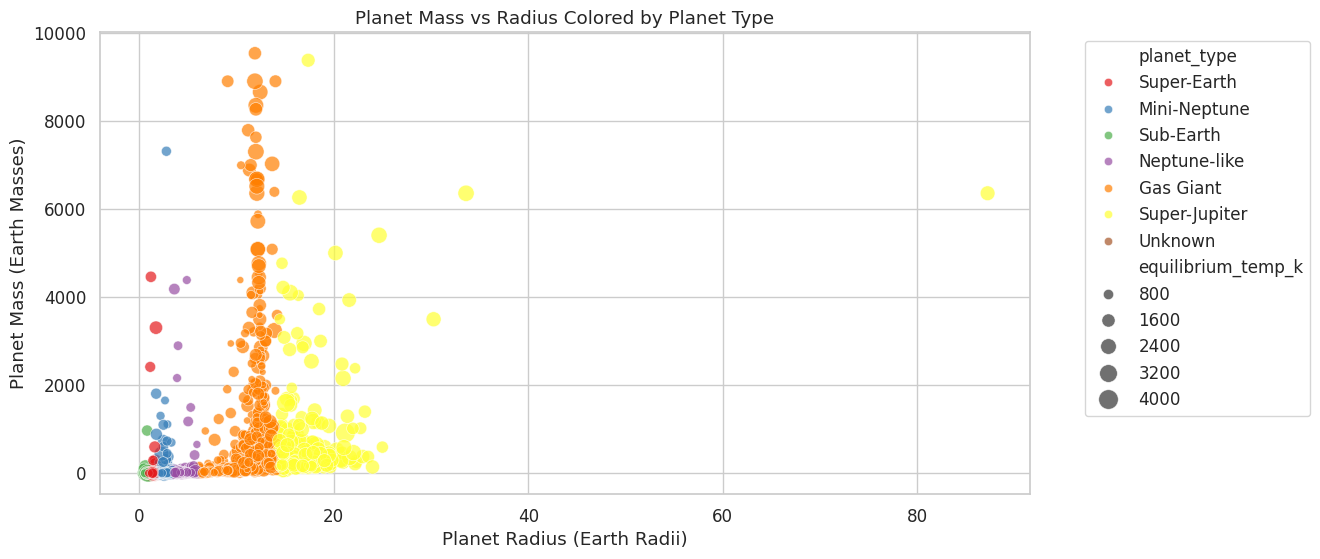

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='planet_radius_earth', y='planet_mass_earth',
                hue='planet_type', size='equilibrium_temp_k', sizes=(20,200),
                palette='Set1', alpha=0.7)
plt.title('Planet Mass vs Radius Colored by Planet Type')
plt.xlabel('Planet Radius (Earth Radii)')
plt.ylabel('Planet Mass (Earth Masses)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

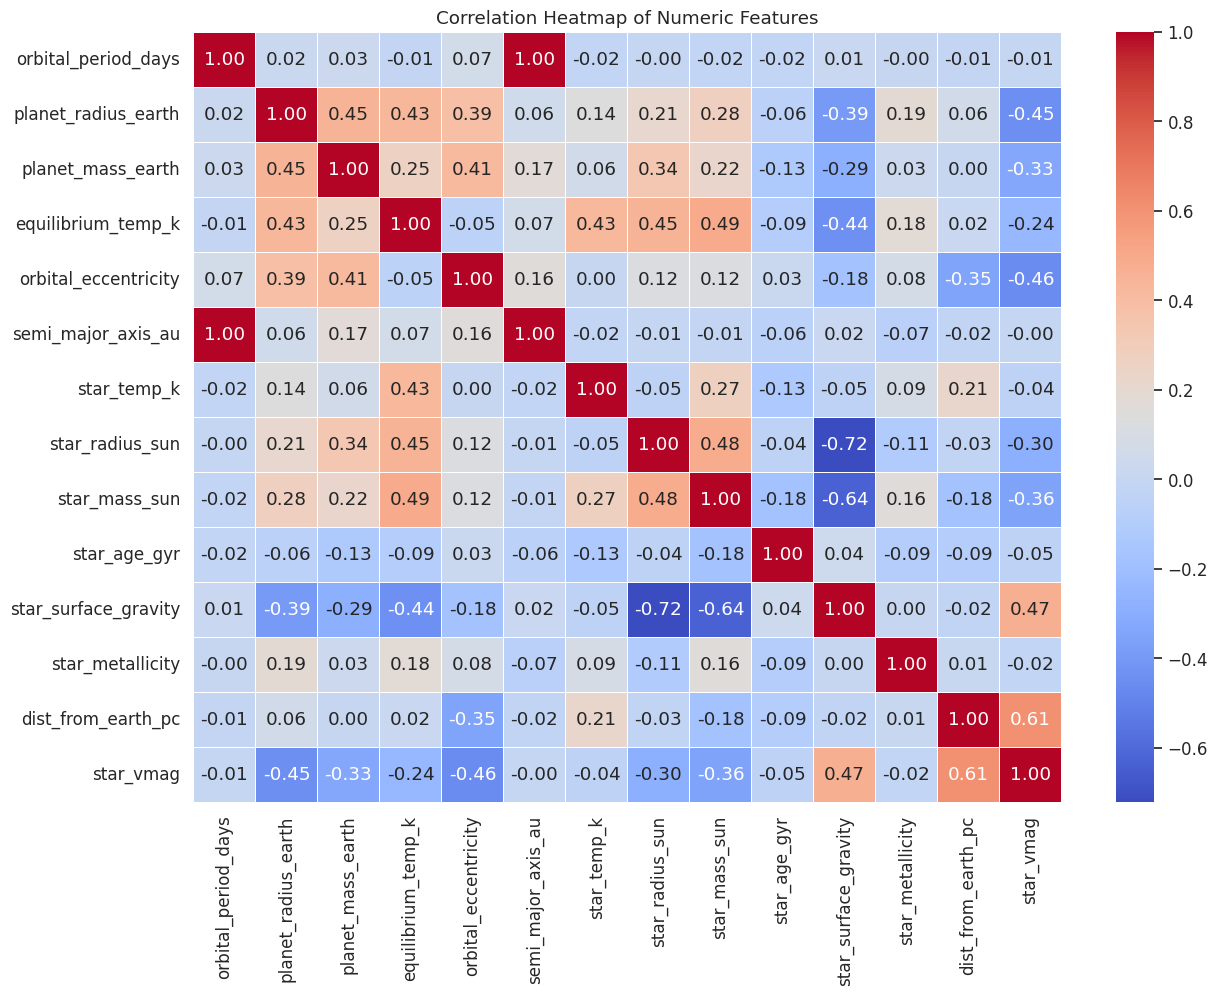

In [20]:
numeric_cols = ['orbital_period_days', 'planet_radius_earth', 'planet_mass_earth',
                'equilibrium_temp_k', 'orbital_eccentricity', 'semi_major_axis_au',
                'star_temp_k', 'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
                'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc', 'star_vmag']

plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


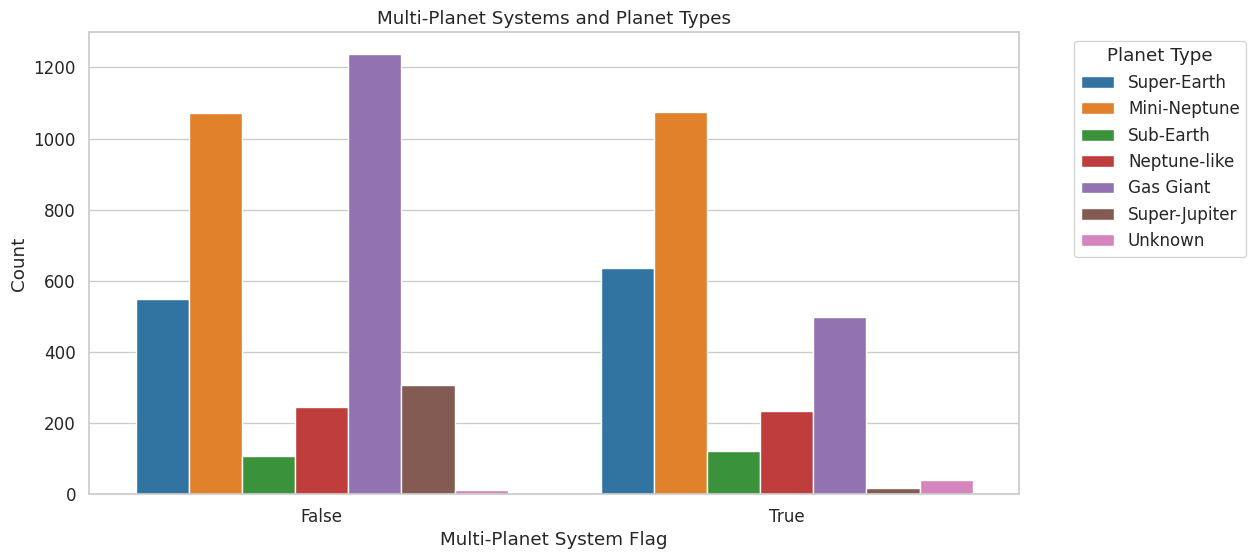

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='multi_planet_system', hue='planet_type', palette='tab10')
plt.title('Multi-Planet Systems and Planet Types')
plt.xlabel('Multi-Planet System Flag')
plt.ylabel('Count')
plt.legend(title='Planet Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Feature engineering

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
target = 'habitable_zone_flag'
features = [
    'n_stars','n_planets','orbital_period_days','planet_radius_earth','planet_mass_earth',
    'equilibrium_temp_k','orbital_eccentricity','semi_major_axis_au','star_temp_k',
    'star_radius_sun','star_mass_sun','star_age_gyr','star_surface_gravity','star_metallicity',
    'dist_from_earth_pc','star_vmag','multi_planet_system','is_recent_discovery'
]

In [24]:
categorical_cols = ['planet_type','discovery_method','disc_facility','dist_category','star_type','orbital_period_cat']


In [25]:
df = df[features + categorical_cols + [target]]  # keep only relevant columns
df = df.dropna()

In [26]:
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [27]:
X = df[features + categorical_cols]
y = df[target]


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
}

results = {}


Logistic Regression Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.99      0.99       697
        True       0.92      0.74      0.82        65

    accuracy                           0.97       762
   macro avg       0.95      0.87      0.90       762
weighted avg       0.97      0.97      0.97       762


Decision Tree Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       697
        True       0.98      1.00      0.99        65

    accuracy                           1.00       762
   macro avg       0.99      1.00      1.00       762
weighted avg       1.00      1.00      1.00       762


Random Forest Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       697
        True       0.97      1.00      0.98        65

    accuracy                           1.00       762
   macro

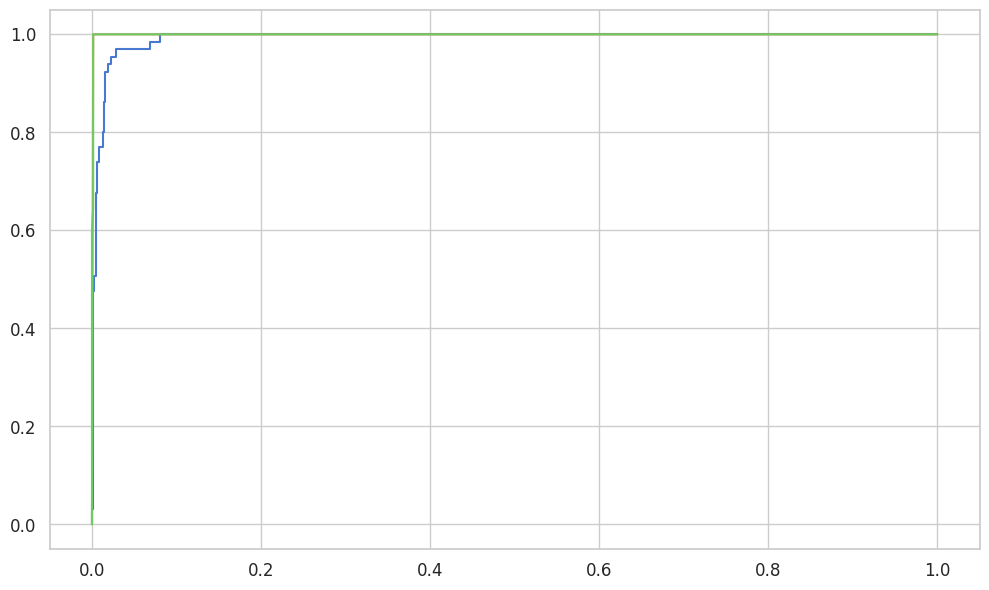

In [31]:
for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree-based models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    results[name] = {'Accuracy': acc, 'ROC AUC': roc_auc}

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')


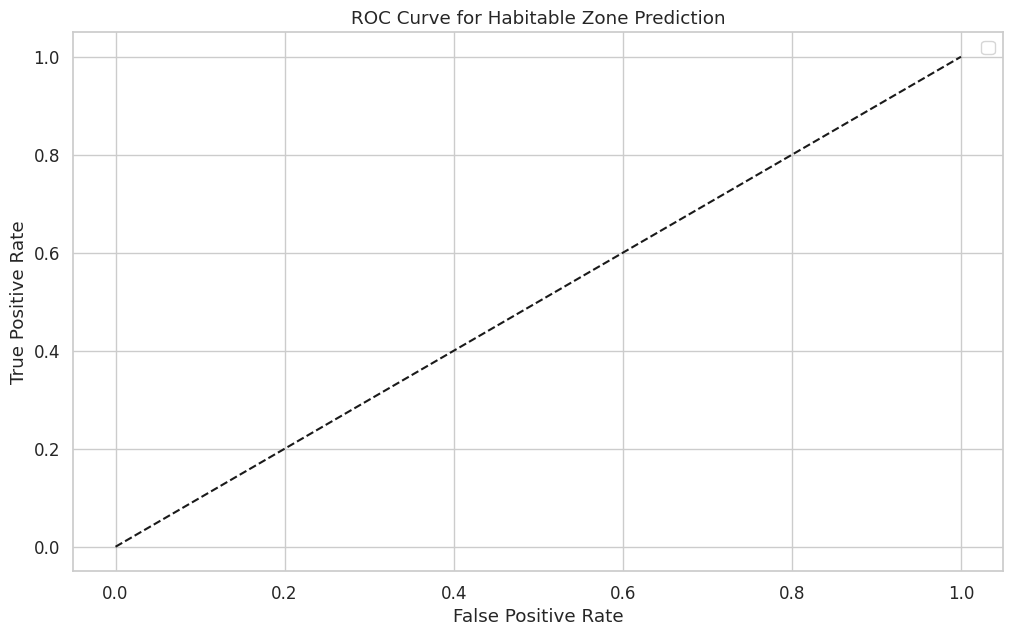

In [32]:
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Habitable Zone Prediction')
plt.legend()
plt.show()

In [33]:
summary_df = pd.DataFrame(results).T
print("\nModel Performance Summary:")
print(summary_df)


Model Performance Summary:
                     Accuracy   ROC AUC
Logistic Regression  0.972441  0.992297
Decision Tree        0.998688  0.999283
Random Forest        0.997375  0.999459


## Thank you...pls upvote!!!!!!!